### Import Nesaseeries


In [221]:
import pandas as pd
import matplotlib. pyplot as plt


### Data Collection


In [222]:
clinets_data = pd.read_csv('insurance_data.csv')
clinets_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


### Data Understanding

In [223]:
clinets_data.shape

(1340, 7)

In [224]:
clinets_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [225]:
clinets_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

### Data Peparasion

In [226]:
clinets_data.dropna()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [227]:
1340-1096


244

### This data 244 Records not proparley so droped dataes

In [228]:
X = clinets_data.drop(labels = ['CASENUM','ATTORNEY'],axis=1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1335,0.0,1.0,0.0,NaN,0.576
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [229]:
y = clinets_data['ATTORNEY']


In [230]:
from sklearn. model_selection import train_test_split

In [231]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True,random_state=34)


In [232]:
X_train.shape, y_train.shape

((1072, 5), (1072,))

In [233]:
X_test.shape, y_test.shape

((268, 5), (268,))

### Model Bulding

In [234]:
from sklearn . tree import DecisionTreeClassifier,plot_tree

In [268]:
decision_model = DecisionTreeClassifier(criterion='gini',max_depth=3)

In [269]:
from sklearn.model_selection import GridSearchCV

In [270]:
grid_search = GridSearchCV(estimator = decision_model,param_grid = {'max_depth':[3,4,5,6,7,8,9],
                                                     "criterion":["gini","entropy"]})
grid_search.fit(X_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 3}
0.7266768093892632


### Model 

In [271]:
decision_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<function matplotlib.pyplot.show(close=None, block=None)>

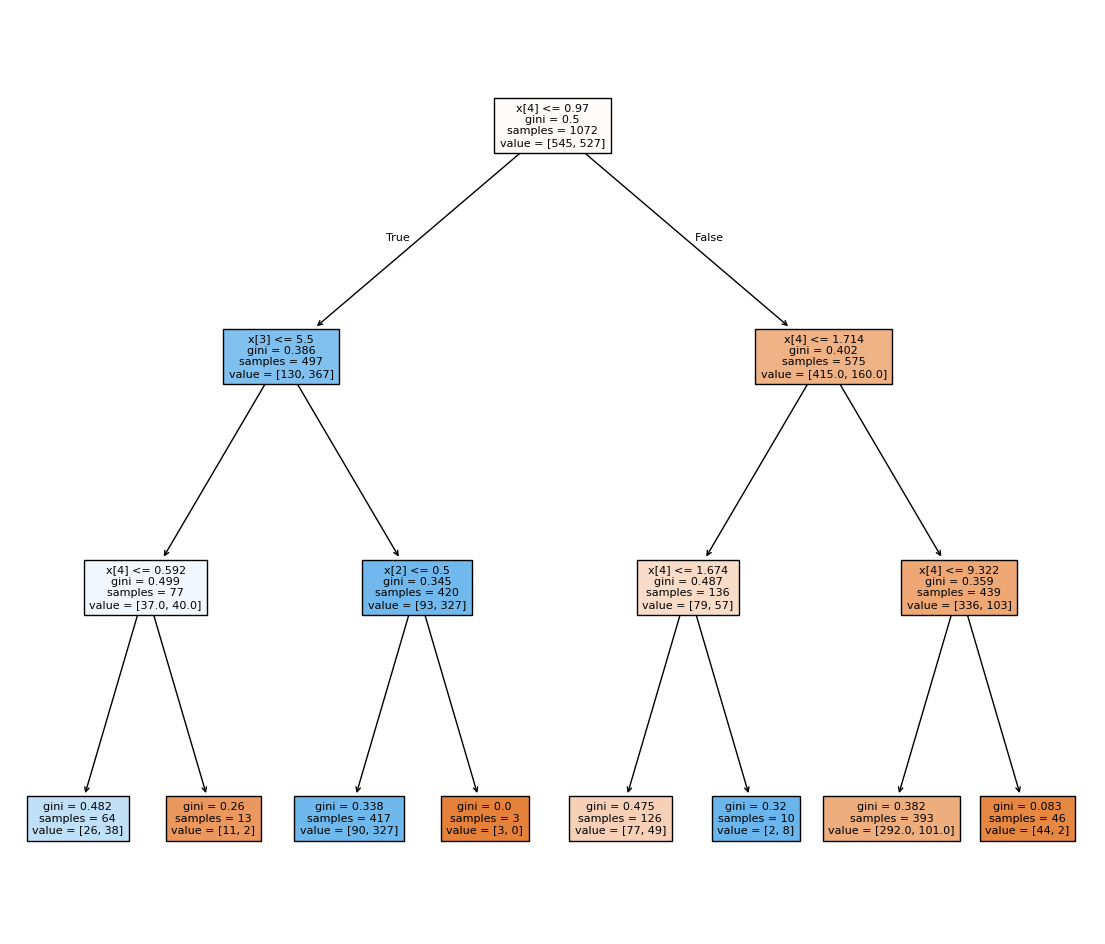

In [272]:
plt.figure(figsize=(14,12))
plot_tree(decision_tree= decision_model,fontsize=8, filled=True  )
plt.show




### Model Testing

In [273]:
y_pred_traning = decision_model.predict(X_train)
y_pred_traning

array([0, 0, 1, ..., 1, 1, 1], shape=(1072,))

In [274]:
y_pred_test = decision_model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1])

### Model Evaluvation Metrics

In [275]:
from sklearn. metrics import accuracy_score, classification_report,confusion_matrix, roc_auc_score

### 1.1 Model Traning Evaluvation

In [276]:
accuracy_score(y_train,y_pred_traning)

0.746268656716418

In [277]:
print(classification_report(y_train,y_pred_traning))

              precision    recall  f1-score   support

           0       0.73      0.78      0.76       545
           1       0.76      0.71      0.73       527

    accuracy                           0.75      1072
   macro avg       0.75      0.75      0.75      1072
weighted avg       0.75      0.75      0.75      1072



In [278]:
confusion_matrix(y_train,y_pred_traning)

array([[427, 118],
       [154, 373]])

In [279]:
roc_auc_score(y_train,y_pred_traning)

0.7456330623400589

### 1.2 Model Testing Veluvation

In [280]:
accuracy_score(y_test,y_pred_test)

0.7014925373134329

In [281]:
confusion_matrix(y_test,y_pred_test)

array([[105,  35],
       [ 45,  83]])

### Model Development

In [282]:
from pickle import dump


In [283]:
dump(decision_model,open("Dt_tree.pkl","wb"))

### The End